# Demonstration of loading and calling pre-trained (Prospector-$\alpha$+) model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# plot settings
columnwidth = 30 # cm
aspect = 1.67
pts_per_inch = 72.27
inch_per_cm = 2.54
width = columnwidth/inch_per_cm
plt.rcParams.update({'figure.figsize': [width, width / aspect],
                     'font.size': 15,
                     'legend.fontsize': 15,
                     'legend.frameon': False,
                     'legend.loc': 'best',
                     'lines.markersize': 3,
                     'lines.linewidth': 2,
                     'axes.linewidth': .5,
                     'axes.edgecolor': 'black'})

## Load trained Prospector-$\alpha$+ models for three wavelength ranges 
UV (1000-4000Å), optical-NIR (4000-11000Å), IR (11000-30000Å)

In [2]:
model_UV = torch.load('../trained_models/speculator_1000_4000.pt', map_location='cpu')
model_optical = torch.load('../trained_models/speculator_4000_11000.pt', map_location='cpu')
model_IR = torch.load('../trained_models/speculator_11000_30000.pt', map_location='cpu')

## Try some input parameters

The example models here use the same SPS parametrization as the `pop-cosmos` model (Alsing et al. [2024](https://ui.adsabs.harvard.edu/abs/2024ApJS..274...12A/abstract); Thorp et al. [2025](https://ui.adsabs.harvard.edu/abs/2025ApJ...993..240T/abstract)). This includes one extra parameter (gas ionization) compared to the original Speculator paper (Alsing et al. [2020](https://ui.adsabs.harvard.edu/abs/2020ApJS..249....5A/abstract)). The input parameter vector has the following order:

$\theta = \left[\log(Z/\mathrm{Z}_\odot), \Delta\log(\mathrm{SFR})_2, \Delta\log(\mathrm{SFR})_3, \Delta\log(\mathrm{SFR})_4, \Delta\log(\mathrm{SFR})_5, \Delta\log(\mathrm{SFR})_6, \Delta\log(\mathrm{SFR})_7,\\\qquad \sqrt{\tau_2},n, \tau_1/\tau_2, \ln f_\mathrm{AGN}, \ln \tau_\mathrm{AGN}, \log(Z_\mathrm{gas}/\mathrm{Z}_\odot), \log(U_\mathrm{gas}), z\right]$

See Table 1 of the pop-cosmos paper (Alsing et al. [2024](https://ui.adsabs.harvard.edu/abs/2024ApJS..274...12A/abstract)) for definitions and prior limits for each parameter. Note that we use the square root of $\tau_2$ in the pre-trained model but the paper indicates limits for that parameter without the square root. Also, note that redshift is used to define a lookback time only - all emulated spectra are delivered in the rest frame for a given lookback time.

Note that all spectra are delivered for unit stellar mass (i.e. normalized to one solar mass). Therefore you should add $\log(M_\mathrm{form}/\mathrm{M}_\odot)$ to the log spectrum to obtain the correct normalization.

In [3]:
theta = torch.Tensor([[0.0, # log metallicity
                       0, 0, 0, 0, 0, 0, # log SFH ratios
                       1.0, # square root of diffuse dust optical depth
                       0.0, # dust attenuation index
                       1.0, # ratio of birth cloud vs diffuse optical depths
                       0.0, # ln fraction of bolometric luminosity from AGN
                       np.log(10), # log optical depth of AGN dust torus
                       0.0, # log gas phase metallicity
                       -2.0, # log gas ionization
                       1.0 # redshift (used to set lookback time only - see notes above)
                     ]])

## Plot the emulated spectrum

Emulated log spectra can be generated by calling the function `log_spectrum(theta)`. The restframe wavelength ranges for each emulator model are attributes of the class simply called `wavelengths`.

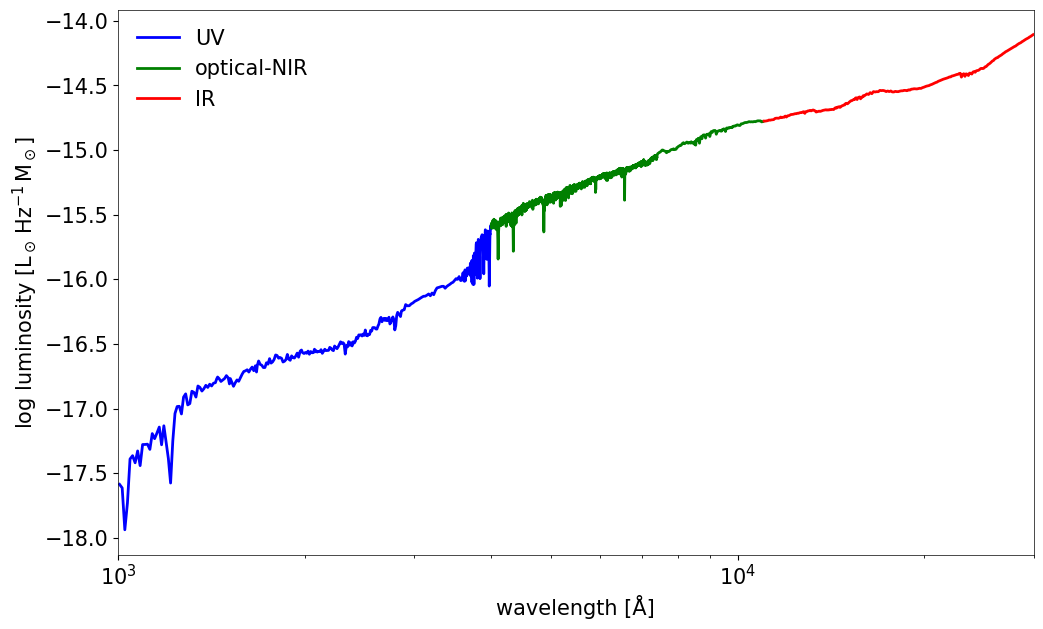

In [4]:
plt.plot(model_UV.wavelengths, model_UV.log_spectrum(theta).detach().numpy().squeeze(), label = 'UV', color = 'blue')
plt.plot(model_optical.wavelengths, model_optical.log_spectrum(theta).detach().numpy().squeeze(), label='optical-NIR', color = 'green')
plt.plot(model_IR.wavelengths, model_IR.log_spectrum(theta).detach().numpy().squeeze(), label='IR', color = 'red')
plt.xlabel('wavelength [Å]')
plt.ylabel('log luminosity [$\\mathrm{L}_\\odot\,\\mathrm{Hz}^{-1}\,\\mathrm{M}_\\odot$]')
plt.legend(frameon=False)
plt.xscale('log')
plt.xlim(1000, 30000)
plt.show()